In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

## __Load dữ liệu__

In [2]:
file_path = "data/yoochoose-clicks.dat"

cols = ["session_id", "timestamp", "item_id", "category"]

df = pd.read_csv(
    file_path,
    names=cols,
    header=None
)

df.head()

C:\Users\hokhi\AppData\Local\Temp\ipykernel_27764\331006662.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,session_id,timestamp,item_id,category
0,1,2014-04-07T10:51:09.277Z,214536502,0
1,1,2014-04-07T10:54:09.868Z,214536500,0
2,1,2014-04-07T10:54:46.998Z,214536506,0
3,1,2014-04-07T10:57:00.306Z,214577561,0
4,2,2014-04-07T13:56:37.614Z,214662742,0


## __Tổng quan kích thước dữ liệu__

In [3]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 33003944
Số cột: 4


## __Kiểu dữ liệu & giá trị null__

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33003944 entries, 0 to 33003943
Data columns (total 4 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   session_id  int64 
 1   timestamp   object
 2   item_id     int64 
 3   category    object
dtypes: int64(2), object(2)
memory usage: 1007.2+ MB


In [5]:
df.isnull().sum()

session_id    0
timestamp     0
item_id       0
category      0
dtype: int64

## __Phân bố số click theo thời gian__

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

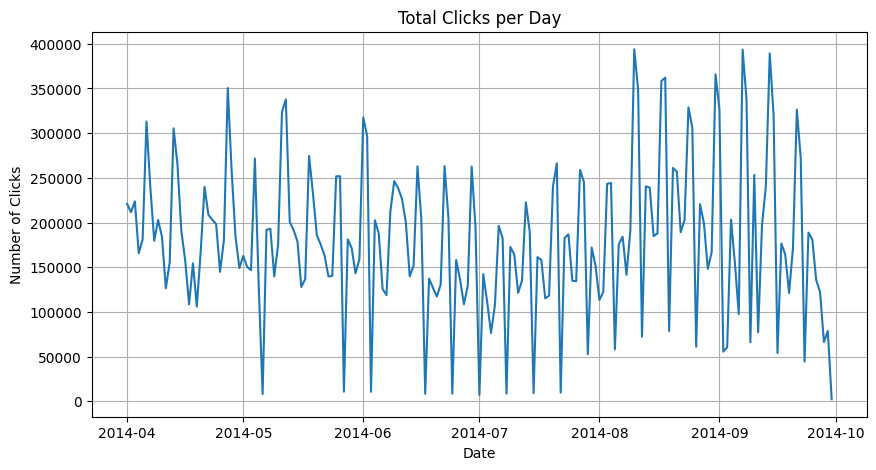

In [9]:
df["date"] = df["timestamp"].dt.date

clicks_per_day = df.groupby("date").size()

plt.figure(figsize=(10,5))
clicks_per_day.plot()
plt.title("Total Clicks per Day")
plt.xlabel("Date")
plt.ylabel("Number of Clicks")
plt.grid(True)
plt.show()

## __Phân tích session__

In [10]:
clicks_per_session = df.groupby("session_id").size()
clicks_per_session.describe()

count    9.249729e+06
mean     3.568098e+00
std      3.787520e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      2.000000e+02
dtype: float64

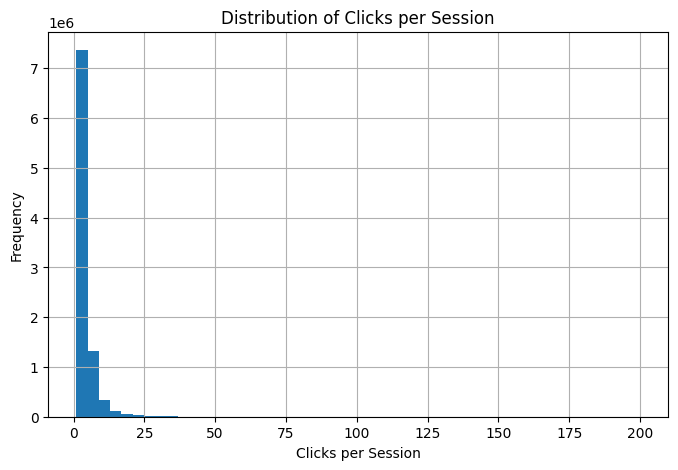

In [11]:
plt.figure(figsize=(8,5))
clicks_per_session.hist(bins=50)
plt.title("Distribution of Clicks per Session")
plt.xlabel("Clicks per Session")
plt.ylabel("Frequency")
plt.show()

## __Bounce session (session chỉ có 1 click)__

In [12]:
bounce_sessions = (clicks_per_session == 1).sum()
total_sessions = clicks_per_session.count()

print("Bounce sessions:", bounce_sessions)
print("Total sessions:", total_sessions)
print("Bounce rate:", bounce_sessions / total_sessions)

Bounce sessions: 1259711
Total sessions: 9249729
Bounce rate: 0.13618896294150887


## __Phân tích item (sản phẩm)__

In [13]:
top_items = (
    df.groupby("item_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

top_items

item_id
643078800    147419
214853094    125690
214829878    113488
214853420     78448
214826610     69710
214853096     66067
214748336     62150
214834880     61668
214839973     60332
214821309     55854
dtype: int64

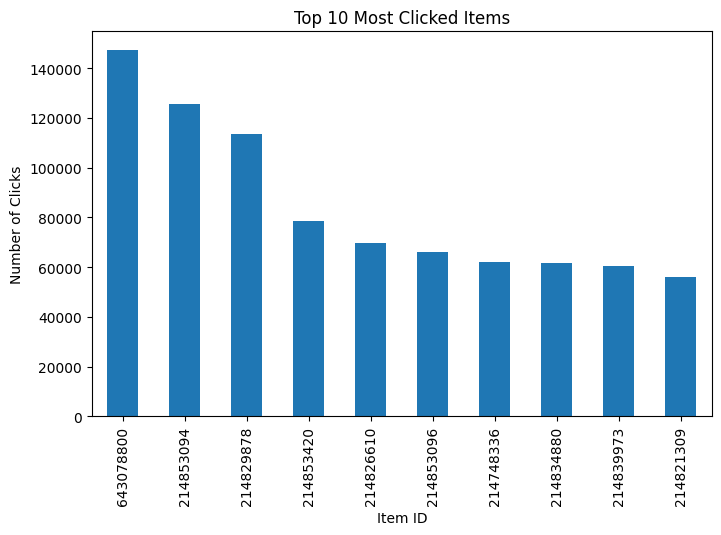

In [14]:
plt.figure(figsize=(8,5))
top_items.plot(kind="bar")
plt.title("Top 10 Most Clicked Items")
plt.xlabel("Item ID")
plt.ylabel("Number of Clicks")
plt.show()

## __Phân tích category__

In [15]:
df["category"].value_counts()

category
0             14548992
S             10769610
0              1788661
1              1671754
2              1292249
                ...   
2089179505           1
2089318108           1
193464283            1
2089028904           1
2089314263           1
Name: count, Length: 340, dtype: int64

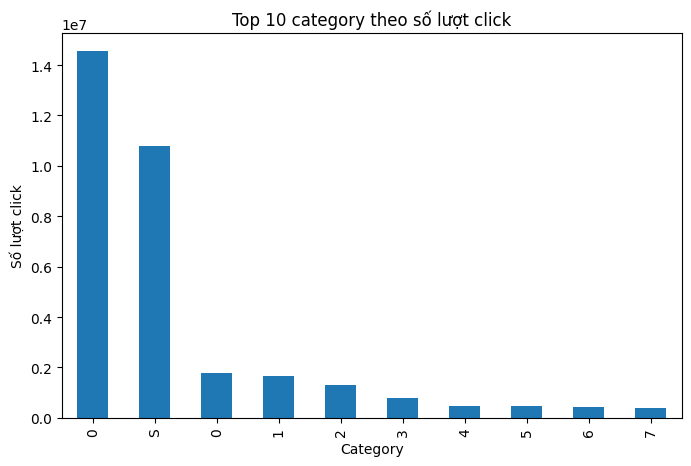

: 

In [18]:
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts()

top10 = category_counts.head(10)

plt.figure(figsize=(8, 5))
top10.plot(kind="bar")
plt.title("Top 10 category theo số lượt click")
plt.xlabel("Category")
plt.ylabel("Số lượt click")
plt.show()